## Notebook for Visualization Analysis on "x"-phyta Level

### Preprocess

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import itertools

xls = pd.ExcelFile('2019年藻类和水温.xlsx')
df_algae = xls.parse('藻类计数')
df_temp = xls.parse('水温')

df_algae['日期'] = pd.to_datetime(df_algae['时间'])
df_algae['物种'] = df_algae['属'].astype(str) + '_' + df_algae['种'].astype(str)
st_cols = [c for c in df_algae.columns if c.startswith('St')]
df_algae['丰度'] = df_algae[st_cols].sum(axis=1)
df_agg = df_algae.groupby(['物种','日期'], as_index=False)['丰度'].sum()

import pandas as pd

df_temp['年月'] = pd.to_datetime(
    df_temp[['年', '月']].rename(columns={'年': 'year', '月': 'month'}).assign(day=1)
)

df_temp_wide = (
    df_temp.pivot_table(index='年月',        
                        columns='点位',
                        values='水温',
                        aggfunc='mean')     
            .rename(columns=lambda s: s.replace('S', 'St'))
            .reset_index()
)


df_algae['年月'] = pd.to_datetime(df_algae['日期']).dt.to_period('M').dt.to_timestamp()  

df_algae_merge = df_algae.merge(df_temp_wide, on='年月', how='left')

df_algae_merge

,时间,属,种,St1_x,St2_x,St3_x,St4_x,St5_x,St6_x,St7_x,...,St11_y,St12_y,St2_y,St3_y,St4_y,St5_y,St6_y,St7_y,St8_y,St9_y
0,2019-01-15,金藻,锥囊藻,0.0,0.00,0.00,0.00,0.0,0.00,0.0,...,7.139333,6.534333,6.189000,6.212333,6.712,6.427000,6.478333,6.428667,6.496667,6.711667
1,2019-01-15,裸藻,纤细裸藻Euglena gracilis Klebs.,0.0,0.00,54320.99,0.00,0.0,0.00,0.0,...,7.139333,6.534333,6.189000,6.212333,6.712,6.427000,6.478333,6.428667,6.496667,6.711667
2,2019-01-15,甲藻,角甲藻,0.0,0.00,0.00,0.00,0.0,0.00,0.0,...,7.139333,6.534333,6.189000,6.212333,6.712,6.427000,6.478333,6.428667,6.496667,6.711667
3,2019-01-15,甲藻,裸甲藻,0.0,0.00,0.00,0.00,0.0,0.00,0.0,...,7.139333,6.534333,6.189000,6.212333,6.712,6.427000,6.478333,6.428667,6.496667,6.711667
4,2019-01-15,甲藻,刺角藻,0.0,0.00,0.00,0.00,0.0,0.00,0.0,...,7.139333,6.534333,6.189000,6.212333,6.712,6.427000,6.478333,6.428667,6.496667,6.711667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,2019-12-14,蓝藻,阿氏拟鱼腥藻,0.0,0.00,0.00,0.00,0.0,0.00,0.0,...,8.595333,8.355000,8.592333,8.316333,8.395,8.268667,8.313667,8.458667,8.287000,8.236333
886,2019-12-14,蓝藻,屈氏平裂藻Merismopedia trolleri Backmann.,0.0,0.00,0.00,0.00,0.0,0.00,0.0,...,8.595333,8.355000,8.592333,8.316333,8.395,8.268667,8.313667,8.458667,8.287000,8.236333
887,2019-12-14,蓝藻,细小平裂藻,0.0,0.00,0.00,0.00,0.0,0.00,0.0,...,8.595333,8.355000,8.592333,8.316333,8.395,8.268667,8.313667,8.458667,8.287000,8.236333
888,2019-12-14,蓝藻,拟鱼腥藻,0.0,33333.33,0.00,66666.67,0.0,33333.33,0.0,...,8.595333,8.355000,8.592333,8.316333,8.395,8.268667,8.313667,8.458667,8.287000,8.236333


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df_algae['Date'] = pd.to_datetime(df_algae['日期'])
df_algae['YM']   = df_algae['Date'].dt.to_period('M')      # 2019-01, …

df_temp_wide['YM'] = df_temp_wide['年月'].dt.to_period('M')

month_to_label = (
    df_algae[['YM', 'Date']]
      .drop_duplicates('YM')
      .set_index('YM')['Date']        # Series: YM → Timestamp
)

temp_cols = [c for c in df_temp_wide.columns if c.startswith('St')]
df_temp_month = (
    df_temp_wide
      .assign(T_avg=lambda d: d[temp_cols].mean(axis=1))   
      [['YM', 'T_avg']]
)

algae_cols = [c for c in df_algae.columns if c.startswith('St')]
df_algae_grp = (
    df_algae
      .assign(total=lambda d: d[algae_cols].sum(axis=1))   
      .groupby(['YM', '属'], as_index=False)['total'].sum()
)

# pivot：index=YM, columns=属, values=丰度
df_alg_pivot = (
    df_algae_grp
      .pivot(index='YM', columns='属', values='total')
      .fillna(0)
)

df_all = df_alg_pivot.merge(df_temp_month, on='YM', how='inner')

peak_temp_month = df_all.loc[df_all['T_avg'].idxmax(), 'YM']

records = []
for col in df_alg_pivot.columns:
    peak_month = df_all.loc[df_all[col].idxmax(), 'YM']
    if peak_month == peak_temp_month:
        cat = 'Same month as Temp Peak'
    elif peak_month > peak_temp_month:
        cat = 'Peaks After Temp Peak'
    else:
        cat = 'Peaks Before Temp Peak'
    records.append(
        {'Phylum': col,
         'Algal Peak': peak_month.strftime('%Y-%m'),
         'Temp Peak':  peak_temp_month.strftime('%Y-%m'),
         'Category':  cat}
    )

df_summary = (pd.DataFrame(records)
                .sort_values('Category')
                .reset_index(drop=True))

print('\n=== Algal peak vs. temperature peak ===')
print(df_summary.to_string(index=False))


x_labels = (month_to_label.loc[df_all['YM']]
              .dt.strftime('%Y-%m-%d')
              .tolist())

plt.figure(figsize=(12, 8))
plt.grid(True, linestyle='--', alpha=0.4)


plt.plot(x_labels, df_all['T_avg'],
         color='red', marker='o', linewidth=2,
         label='Water Temperature (°C)')

colors = plt.cm.tab10(np.linspace(0, 1, len(df_alg_pivot.columns)))
temp_max = df_all['T_avg'].max()

algae_en = {
    '蓝藻': 'Cyanophyta',
    '绿藻': 'Chlorophyta',
    '甲藻': 'Dinophyta',
    '金藻': 'Chrysophyta',
    '裸藻': 'Euglenophyta',
    '硅藻': 'Bacillariophyta',
    '隐藻': 'Cryptophyta',
    # Others
}

# for i, col in enumerate(df_alg_pivot.columns):
#     if df_all[col].max() == 0:
#         continue
#     norm_vals = df_all[col] / df_all[col].max() * temp_max
#     label_en = algae_en.get(col, col)
#     plt.plot(x_labels, norm_vals,
#              color=colors[i], marker='o',
#              label=label_en)

# plt.xlabel('Date')
# plt.ylabel('Value (Temperature & Normalised Abundance)')
# plt.title('Monthly Water Temperature vs Algal Abundance')
# plt.xticks(rotation=45)

# handles, labels = plt.gca().get_legend_handles_labels()
# plt.legend(handles, labels,
#            ncol=len(labels),
#            fontsize=8,
#            loc='upper center',
#            bbox_to_anchor=(0.5, -0.12),
#            frameon=False)
# plt.tight_layout()
# plt.subplots_adjust(bottom=0)
# plt.show()


=== Algal peak vs. temperature peak ===
Phylum Algal Peak Temp Peak               Category
    甲藻    2019-12   2019-08  Peaks After Temp Peak
    裸藻    2019-09   2019-08  Peaks After Temp Peak
    金藻    2019-11   2019-08  Peaks After Temp Peak
    隐藻    2019-12   2019-08  Peaks After Temp Peak
    硅藻    2019-05   2019-08 Peaks Before Temp Peak
    绿藻    2019-05   2019-08 Peaks Before Temp Peak
    蓝藻    2019-01   2019-08 Peaks Before Temp Peak


### All: algal_three_panel.pdf

Saved PDF to: algal_three_panel_all.pdf


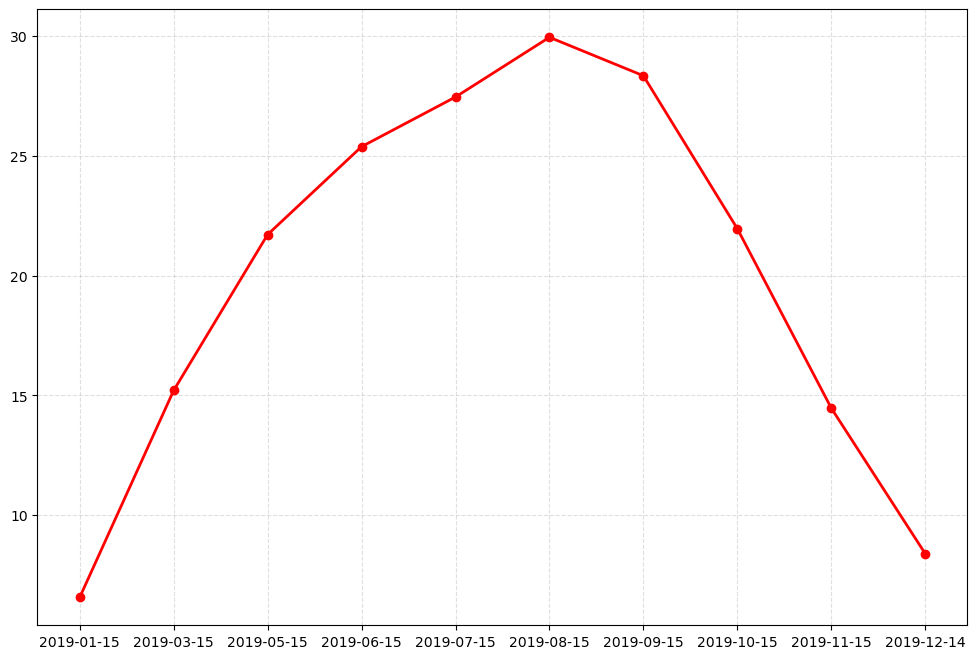

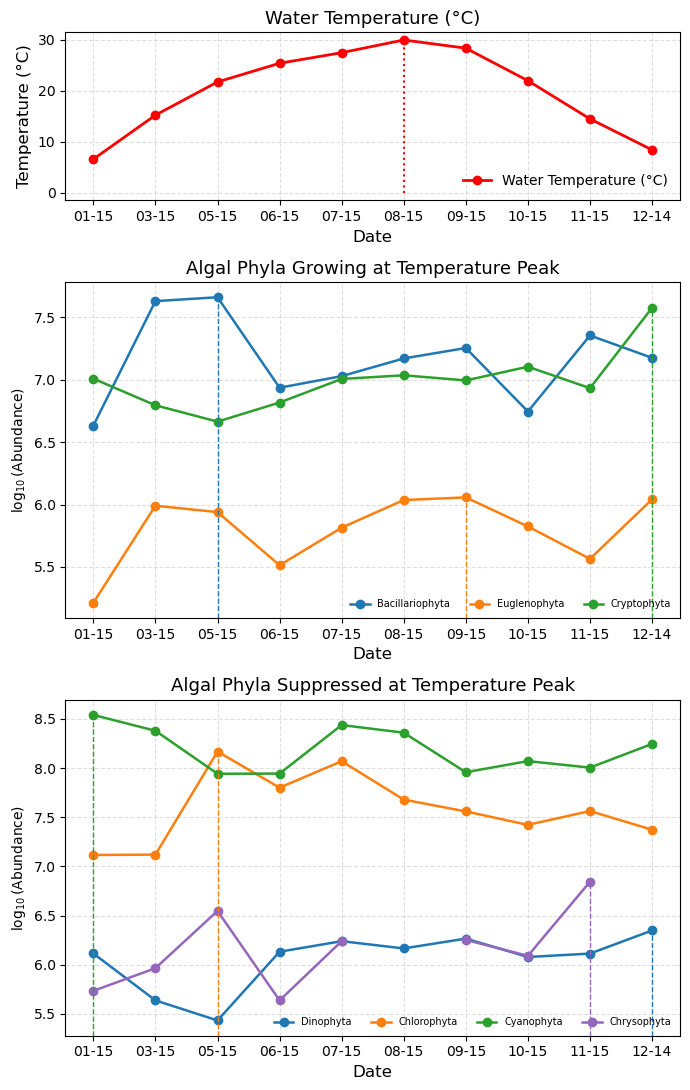

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def strip_2019(label: str) -> str:
    if isinstance(label, str) and (label.startswith("2019-") or label.startswith("2019/")):
        return label[5:]
    return label

x_labels_wo_year = [strip_2019(lbl) for lbl in x_labels]

peak_idx = int(df_all['T_avg'].idxmax())
growth_species = [
    phylum for phylum in df_alg_pivot.columns
    if peak_idx > 0 and df_all[phylum].iloc[peak_idx] > df_all[phylum].iloc[peak_idx - 1]
]
no_growth_species = [p for p in df_alg_pivot.columns if p not in growth_species]

def plot_group_on_ax(ax, species_list, zero_cutoff=1.0, eps=1e-6):
    cmap = plt.get_cmap('tab10')
    base_colors = list(cmap.colors)
    algae_colors = [c for i, c in enumerate(base_colors) if i != 3]

    x = np.arange(len(x_labels_wo_year))
    plotted_mins, plotted_maxs = [], []
    peak_lines = []  # (x_idx, y_peak, color)

    for i, phylum in enumerate(species_list):
        vals = df_all[phylum].values.astype(float)
        vals_masked = vals.copy()
        vals_masked[vals_masked <= zero_cutoff] = np.nan
        if np.isnan(vals_masked).all():
            continue

        vals_log = np.where(np.isnan(vals_masked), np.nan, np.log10(vals_masked + eps))

        color = algae_colors[i % len(algae_colors)]
        ax.plot(x, vals_log, marker='o', linewidth=1.8, color=color,
                label=algae_en.get(phylum, phylum))

        ap = int(np.nanargmax(vals_masked))
        y_peak = np.log10(vals_masked[ap] + eps)
        peak_lines.append((ap, y_peak, color))

        finite_vals = vals_log[np.isfinite(vals_log)]
        plotted_mins.append(np.nanmin(finite_vals))
        plotted_maxs.append(np.nanmax(finite_vals))

    ax.set_ylabel(r'$\log_{10}(\mathrm{Abundance})$')
    ax.grid(True, linestyle='--', alpha=0.4)

    handles, labels = ax.get_legend_handles_labels()
    if labels:
        ncol = max(1, min(len(labels), 4))
        ax.legend(handles, labels, ncol=ncol, fontsize=7,
                  loc='lower right', frameon=False)

    return plotted_mins, plotted_maxs, peak_lines

def plot_3row_layout(zero_cutoff=1.0, eps=1e-6, pdf_path="algal_three_panel.pdf"):
    x = np.arange(len(x_labels_wo_year))
    tvals = df_all['T_avg'].values

    fig, (ax_t, ax_grow, ax_supp) = plt.subplots(
        3, 1, sharex=True, figsize=(7, 11),
        gridspec_kw={'height_ratios': [1.0, 2.0, 2.0]}
    )

    ax_t.plot(x, tvals, color='red', marker='o', linewidth=2, label='Water Temperature (°C)')
    ax_t.vlines(int(peak_idx), 0, tvals[int(peak_idx)], colors='red', linestyles=':', linewidth=1.5)
    ax_t.set_ylabel('Temperature (°C)', fontsize=12)
    ax_t.set_title('Water Temperature (°C)', fontsize=13)
    ax_t.grid(True, linestyle='--', alpha=0.4)
    ax_t.legend(loc='lower right', frameon=False, fontsize=10)

    mins1, maxs1, peaks1 = plot_group_on_ax(ax_grow, growth_species, zero_cutoff, eps)
    ax_grow.set_title('Algal Phyla Growing at Temperature Peak', fontsize=13)

    mins2, maxs2, peaks2 = plot_group_on_ax(ax_supp, no_growth_species, zero_cutoff, eps)
    ax_supp.set_title('Algal Phyla Suppressed at Temperature Peak', fontsize=13)

    def finalize_axes(ax, mins, maxs, peaks):
        if mins and maxs:
            ymin, ymax = min(mins), max(maxs)
            if np.isfinite(ymin) and np.isfinite(ymax) and ymax > ymin:
                pad = 0.05 * (ymax - ymin)
                ax.set_ylim(ymin - pad, ymax + pad)
        y_bottom = ax.get_ylim()[0]
        for ap, y_peak, color in peaks:
            ax.vlines(ap, y_bottom, y_peak, colors=color, linestyles='--', linewidth=1)

    finalize_axes(ax_grow, mins1, maxs1, peaks1)
    finalize_axes(ax_supp, mins2, maxs2, peaks2)

    xticks = x
    tick_labels = x_labels_wo_year
    for ax in (ax_t, ax_grow, ax_supp):
        ax.set_xticks(xticks)
        ax.set_xticklabels(tick_labels, rotation=0, ha='center', fontsize=10)
        ax.set_xlabel('Date', fontsize=12)
        ax.xaxis.set_tick_params(labelbottom=True)

    plt.subplots_adjust(hspace=0.18, left=0.10, right=0.98, top=0.92, bottom=0.12)
    plt.tight_layout(rect=(0, 0, 1, 1))

    try:
        fig.savefig(pdf_path, format='pdf', bbox_inches='tight')
        print(f"Saved PDF to: {pdf_path}")
    except Exception as e:
        print(f"Warning: failed to save PDF: {e}")

    plt.show()

plot_3row_layout(zero_cutoff=1.0, pdf_path="algal_three_panel_all.pdf")

### 6-10: algal_three_panel

Saved PDF to: algal_three_panel_06-10.pdf


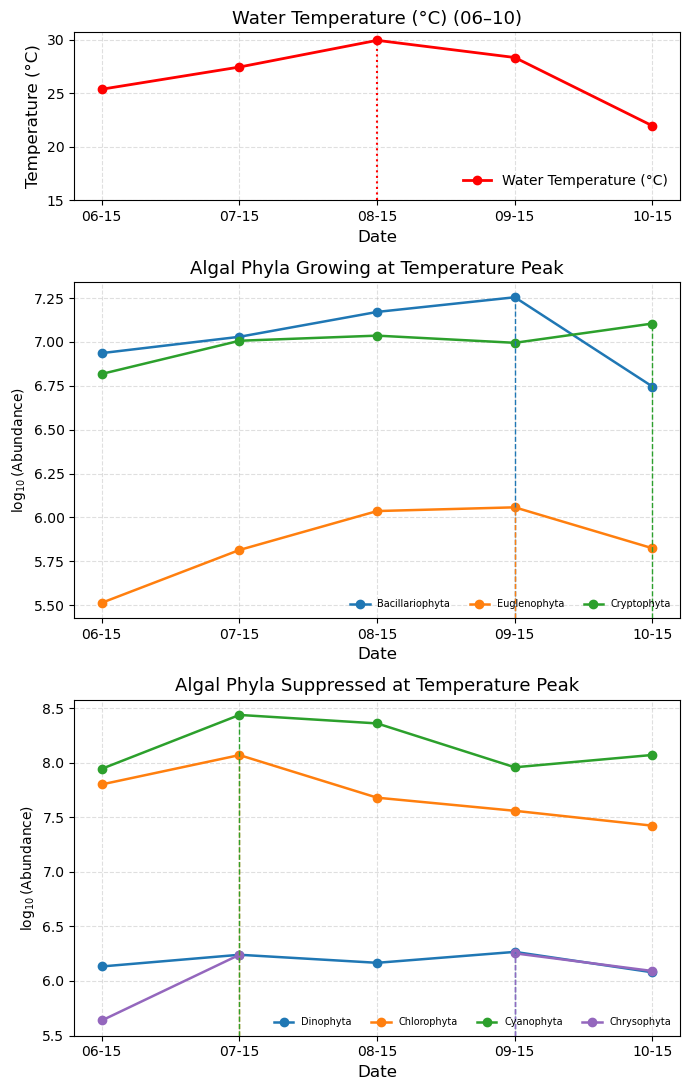

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def strip_2019(label: str) -> str:
    if isinstance(label, str) and (label.startswith("2019-") or label.startswith("2019/")):
        return label[5:]
    return label

x_labels_wo_year = [strip_2019(lbl) for lbl in x_labels]

def extract_months(labels):
    months = []
    for lbl in labels:
        if not isinstance(lbl, str):
            months.append(None)
            continue
        sep = '-' if '-' in lbl else ('/' if '/' in lbl else None)
        if sep is None:
            try:
                months.append(int(lbl[:2]) if lbl[:2].isdigit() else int(lbl[:1]))
            except:
                months.append(None)
        else:
            try:
                months.append(int(lbl.split(sep)[0]))
            except:
                months.append(None)
    return months

def plot_group_on_ax(ax, species_list, df, x_labels, zero_cutoff=1.0, eps=1e-6):
    cmap = plt.get_cmap('tab10')
    base_colors = list(cmap.colors)
    algae_colors = [c for i, c in enumerate(base_colors) if i != 3]

    x = np.arange(len(x_labels))
    plotted_mins, plotted_maxs = [], []
    peak_lines = []  # (x_idx, y_peak, color)

    for i, phylum in enumerate(species_list):
        if phylum not in df.columns:
            continue
        vals = df[phylum].values.astype(float)
        vals_masked = vals.copy()
        vals_masked[vals_masked <= zero_cutoff] = np.nan
        if np.isnan(vals_masked).all():
            continue

        vals_log = np.where(np.isnan(vals_masked), np.nan, np.log10(vals_masked + eps))

        color = algae_colors[i % len(algae_colors)]
        ax.plot(x, vals_log, marker='o', linewidth=1.8, color=color,
                label=algae_en.get(phylum, phylum))

        ap = int(np.nanargmax(vals_masked))
        y_peak = np.log10(vals_masked[ap] + eps)
        peak_lines.append((ap, y_peak, color))

        finite_vals = vals_log[np.isfinite(vals_log)]
        plotted_mins.append(np.nanmin(finite_vals))
        plotted_maxs.append(np.nanmax(finite_vals))

    ax.set_ylabel(r'$\log_{10}(\mathrm{Abundance})$')
    ax.grid(True, linestyle='--', alpha=0.4)

    handles, labels = ax.get_legend_handles_labels()
    if labels:
        ncol = max(1, min(len(labels), 4))
        ax.legend(handles, labels, ncol=ncol, fontsize=7,
                  loc='lower right', frameon=False)

    return plotted_mins, plotted_maxs, peak_lines

def plot_3row_layout(month_start=None, month_end=None,
                     zero_cutoff=1.0, eps=1e-6, pdf_path="algal_three_panel.pdf",
                     temp_ymin=5):
    months = extract_months(x_labels_wo_year)
    if month_start is not None and month_end is not None:
        mask = [(m is not None) and (month_start <= m <= month_end) for m in months]
        if not any(mask):
            print(f"Warning: No data for {month_start}–{month_end}, using all data.")
            x_sub = x_labels_wo_year
            df_sub = df_all.reset_index(drop=True)
        else:
            x_sub = [lbl for lbl, keep in zip(x_labels_wo_year, mask) if keep]
            df_sub = df_all.loc[mask].reset_index(drop=True)
            if pdf_path.endswith(".pdf"):
                stem = pdf_path[:-4]
                pdf_path = f"{stem}_{month_start:02d}-{month_end:02d}.pdf"
    else:
        x_sub = x_labels_wo_year
        df_sub = df_all.reset_index(drop=True)

    if 'T_avg' not in df_sub.columns or len(df_sub) == 0:
        raise ValueError("df_all has no 'T_avg' column.")

    peak_idx_local = int(np.nanargmax(df_sub['T_avg'].values))

    phyla = [c for c in df_alg_pivot.columns if c in df_sub.columns]
    growth_species = [
        phylum for phylum in phyla
        if peak_idx_local > 0 and
           np.isfinite(df_sub[phylum].iloc[peak_idx_local]) and
           np.isfinite(df_sub[phylum].iloc[peak_idx_local - 1]) and
           df_sub[phylum].iloc[peak_idx_local] > df_sub[phylum].iloc[peak_idx_local - 1]
    ]
    no_growth_species = [p for p in phyla if p not in growth_species]

    x = np.arange(len(x_sub))
    tvals = df_sub['T_avg'].values

    fig, (ax_t, ax_grow, ax_supp) = plt.subplots(
        3, 1, sharex=True, figsize=(7, 11),
        gridspec_kw={'height_ratios': [1.0, 2.0, 2.0]}
    )

    ax_t.plot(x, tvals, color='red', marker='o', linewidth=2, label='Water Temperature (°C)')

    peak_x = int(peak_idx_local)
    peak_y = float(tvals[peak_x])
    ax_t.vlines(peak_x, temp_ymin, peak_y, colors='red', linestyles=':', linewidth=1.5)

    tmax = float(np.nanmax(tvals)) if len(tvals) else temp_ymin
    upper = max(tmax, temp_ymin) + 0.05 * max(1.0, abs(tmax - temp_ymin))
    if upper <= temp_ymin:
        upper = temp_ymin + 1.0
    ax_t.set_ylim(temp_ymin, upper)

    ax_t.set_ylabel('Temperature (°C)', fontsize=12)
    title_suffix = (f" ({month_start:02d}–{month_end:02d})" if month_start and month_end else "")
    ax_t.set_title(f'Water Temperature (°C){title_suffix}', fontsize=13)
    ax_t.grid(True, linestyle='--', alpha=0.4)
    ax_t.legend(loc='lower right', frameon=False, fontsize=10)

    mins1, maxs1, peaks1 = plot_group_on_ax(ax_grow, growth_species, df_sub, x_sub, zero_cutoff, eps)
    ax_grow.set_title('Algal Phyla Growing at Temperature Peak', fontsize=13)

    mins2, maxs2, peaks2 = plot_group_on_ax(ax_supp, no_growth_species, df_sub, x_sub, zero_cutoff, eps)
    ax_supp.set_title('Algal Phyla Suppressed at Temperature Peak', fontsize=13)

    def finalize_axes(ax, mins, maxs, peaks):
        if mins and maxs:
            ymin, ymax = min(mins), max(maxs)
            if np.isfinite(ymin) and np.isfinite(ymax) and ymax > ymin:
                pad = 0.05 * (ymax - ymin)
                ax.set_ylim(ymin - pad, ymax + pad)
        y_bottom = ax.get_ylim()[0]
        for ap, y_peak, color in peaks:
            ax.vlines(ap, y_bottom, y_peak, colors=color, linestyles='--', linewidth=1)

    finalize_axes(ax_grow, mins1, maxs1, peaks1)
    finalize_axes(ax_supp, mins2, maxs2, peaks2)

    for ax in (ax_t, ax_grow, ax_supp):
        ax.set_xticks(x)
        ax.set_xticklabels(x_sub, rotation=0, ha='center', fontsize=10)
        ax.set_xlabel('Date', fontsize=12)
        ax.xaxis.set_tick_params(labelbottom=True)

    plt.subplots_adjust(hspace=0.18, left=0.10, right=0.98, top=0.92, bottom=0.12)
    plt.tight_layout(rect=(0, 0, 1, 1))

    try:
        fig.savefig(pdf_path, format='pdf', bbox_inches='tight')
        print(f"Saved PDF to: {pdf_path}")
    except Exception as e:
        print(f"Warning: failed to save PDF: {e}")

    plt.show()

# Duration: All year
# plot_3row_layout(pdf_path="algal_three_panel_all.pdf", temp_ymin=5)

# Duration: 6-10
plot_3row_layout(month_start=6, month_end=10, pdf_path="algal_three_panel.pdf", temp_ymin=15)